In [113]:
import numpy as np
import pandas as pd
dt=pd.read_csv(r"C:\Users\hp5cd\Downloads\data.csv.xls")
dt.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [114]:
dt.shape

(569, 33)

In [115]:
dt.drop("Unnamed: 32",axis=1,inplace=True)

In [116]:
dt.shape

(569, 32)

In [117]:
!pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


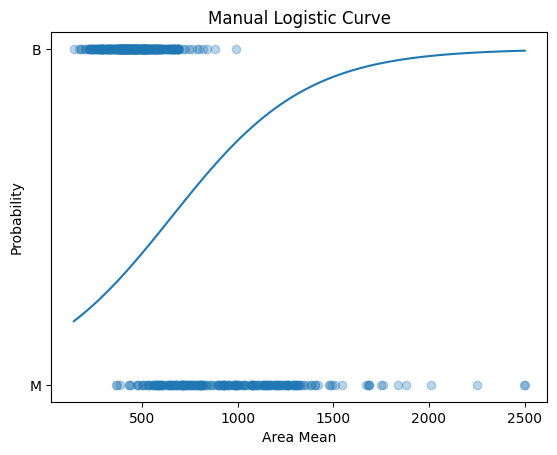

In [119]:
import numpy as np
import matplotlib.pyplot as plt

x = dt["area_mean"]
y = dt["diagnosis"]

plt.scatter(x, y, alpha=0.3)

# Create smooth curve
x_line = np.linspace(x.min(), x.max(), 100)
y_line = 1 / (1 + np.exp(-(x_line - x.mean()) / x.std()))

plt.plot(x_line, y_line)

plt.xlabel("Area Mean")
plt.ylabel("Probability")
plt.title("Manual Logistic Curve")

plt.show()

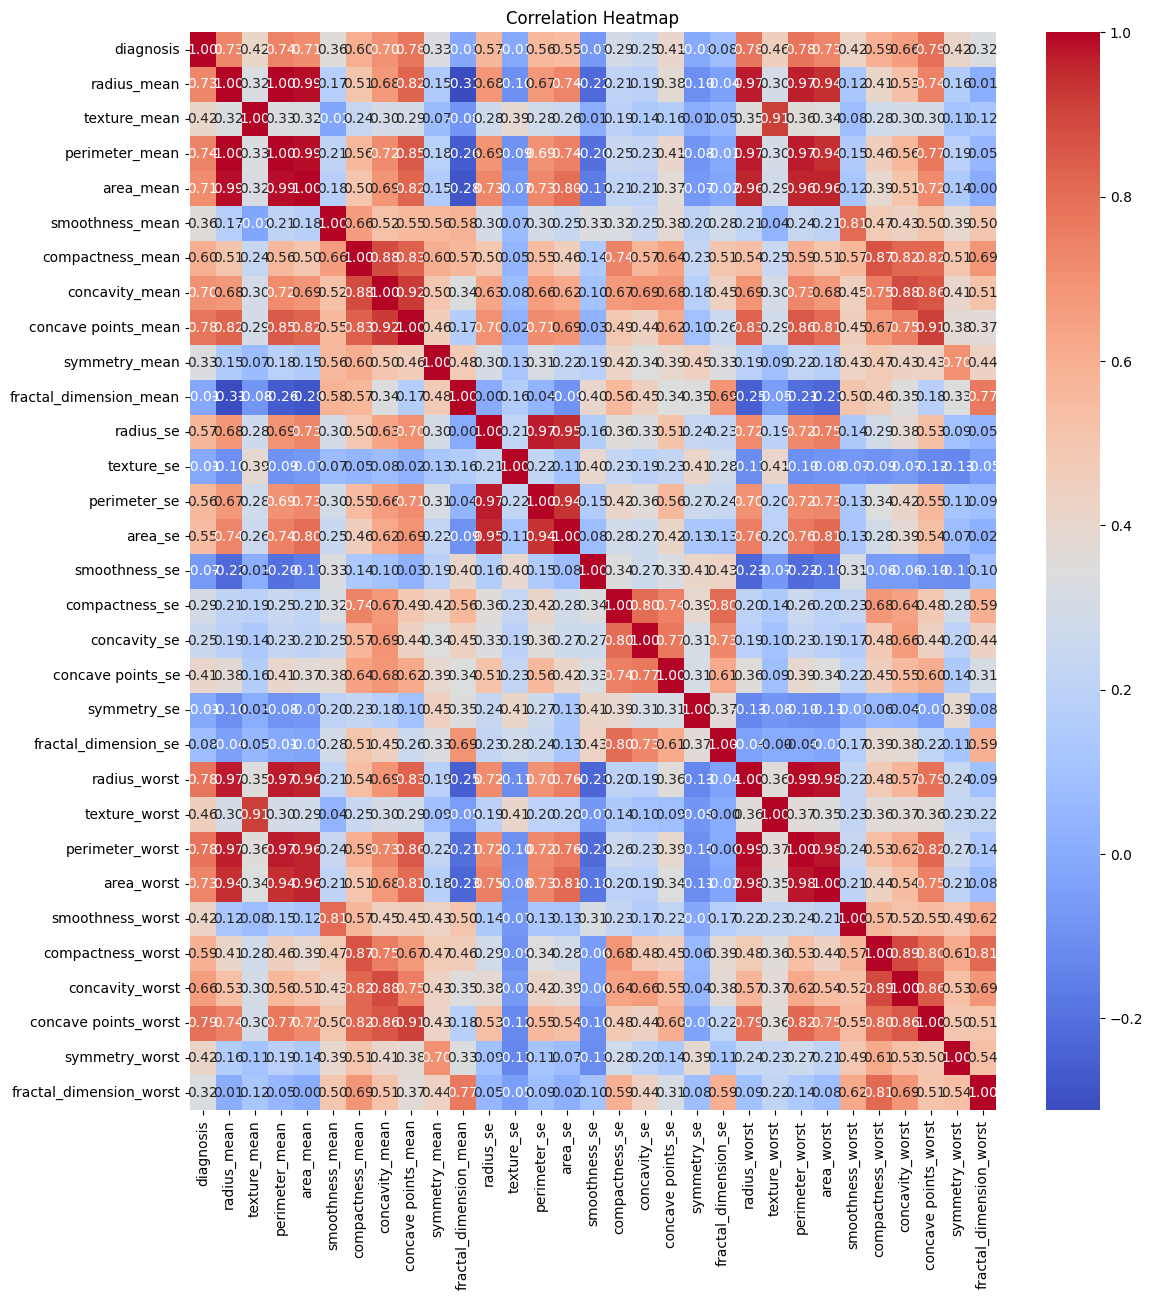

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert diagnosis to numeric
dt["diagnosis"] = dt["diagnosis"].map({"M": 1, "B": 0})

# 2. Drop non-numeric columns (like id if present)
dt = dt.drop(columns=["id"], errors="ignore")

# 3. Compute correlation
Corr = dt.corr()

# 4. Plot heatmap
plt.figure(figsize=(13, 14))
sns.heatmap(Corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [121]:

dt.drop([
    "fractal_dimension_worst",
    "symmetry_se",
    "fractal_dimension_se",
    "smoothness_se",
    "texture_se",
    "fractal_dimension_mean",
    "id"
], axis=1, inplace=True, errors="ignore")

In [122]:
dt.shape

(569, 25)

In [123]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X = dt.drop("diagnosis", axis=1)   # Features
y = dt["diagnosis"]                # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
#bagging
from sklearn.ensemble import RandomForestClassifier
Model=RandomForestClassifier(n_estimators=1000,max_depth=None,random_state=42)
Model.fit(X_train,y_train)
y_prd=Model.predict(X_test)
accuracy_score(y_prd,y_test)

0.9649122807017544

In [124]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test,y_pred)

C:\Users\hp5cd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9649122807017544

In [125]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

base_lr=[("kn",KNeighborsClassifier(n_neighbors=5)),("dt",DecisionTreeClassifier(random_state=42)),
("lr",LogisticRegression(max_iter=1000,random_state=42))]
Metalr=LogisticRegression(max_iter=1000)

from sklearn.ensemble import StackingClassifier
models=StackingClassifier(estimators=base_lr,final_estimator=Metalr,cv=5)
models.fit(X_train,y_train)
y_prds=models.predict(X_test)

print("pridictions:/n",y_prds)
print("expected  ",y_test)
accuracy_score(y_test,y_prds)

C:\Users\hp5cd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\hp5cd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

pridictions:/n [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]
expected   204    0
70     1
131    1
431    0
540    0
      ..
486    0
75     1
249    0
238    0
265    1
Name: diagnosis, Length: 114, dtype: int64


C:\Users\hp5cd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9736842105263158